In [1]:
import pandas as pd
import os

df_t3 = pd.read_csv("Data_SNDT/data_tache_3.csv", sep=',')
print(df_t3.columns.tolist())
print(df_t3.head())
print(df_t3.shape)

['field_file', 'label', 'coverage_type', 'shape', 'noisy', 'pipe_type']
                                      field_file  label coverage_type  \
0  sample_00000_perfect_straight_clean_field.npz      1       perfect   
1  sample_00001_perfect_straight_clean_field.npz      1       perfect   
2  sample_00002_perfect_straight_clean_field.npz      1       perfect   
3  sample_00003_perfect_straight_clean_field.npz      1       perfect   
4  sample_00004_perfect_straight_clean_field.npz      1       perfect   

      shape  noisy pipe_type  
0  straight  False    single  
1  straight  False    single  
2  straight  False    single  
3  straight  False    single  
4  straight  False    single  
(4715, 6)


In [2]:
print(df_t3['label'].value_counts())
print(df_t3['coverage_type'].value_counts())

label
1    2829
0    1886
Name: count, dtype: int64
coverage_type
perfect    3915
offset      600
missed      200
Name: count, dtype: int64


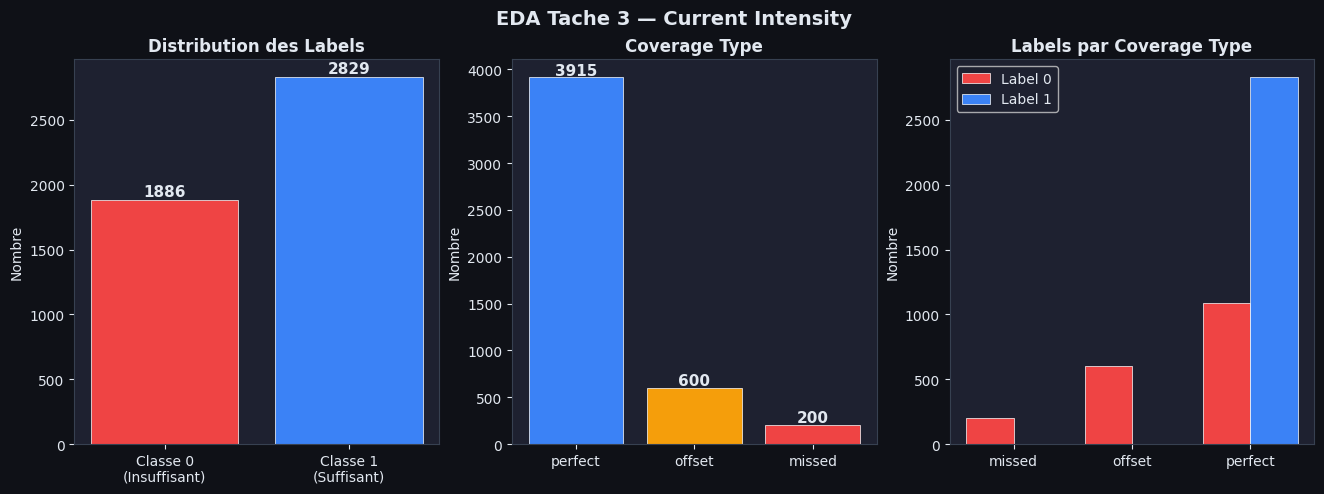

Total : 4715 | Label=1 : 2829 (60.0%) | Label=0 : 1886 (40.0%)
NaN : {'field_file': 0, 'label': 0, 'coverage_type': 0, 'shape': 0, 'noisy': 0, 'pipe_type': 0}


In [3]:
import pandas as pd
import os
import matplotlib.pyplot as plt

df_t3 = pd.read_csv("Data_SNDT/data_tache_3.csv", sep=',')

BG, TEXT = '#1e2130', '#e2e8f0'

def style_ax(ax, title):
    ax.set_facecolor(BG)
    ax.set_title(title, color=TEXT, fontsize=12, fontweight='bold')
    ax.tick_params(colors=TEXT)
    for spine in ax.spines.values(): spine.set_edgecolor('#374151')
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')

# --- Distribution labels ---
counts = df_t3['label'].value_counts().sort_index()
axes[0].bar(['Classe 0\n(Insuffisant)', 'Classe 1\n(Suffisant)'],
            counts.values, color=['#ef4444', '#3b82f6'], edgecolor='white', linewidth=0.5)
for i, val in enumerate(counts.values):
    axes[0].text(i, val + 30, str(val), ha='center', color=TEXT, fontsize=11, fontweight='bold')
style_ax(axes[0], 'Distribution des Labels')
axes[0].set_ylabel('Nombre', color=TEXT)

# --- Coverage type ---
ct = df_t3['coverage_type'].value_counts()
axes[1].bar(ct.index, ct.values, color=['#3b82f6', '#f59e0b', '#ef4444'], edgecolor='white', linewidth=0.5)
for i, val in enumerate(ct.values):
    axes[1].text(i, val + 30, str(val), ha='center', color=TEXT, fontsize=11, fontweight='bold')
style_ax(axes[1], 'Coverage Type')
axes[1].set_ylabel('Nombre', color=TEXT)

# --- Label par coverage_type ---
ct_label = df_t3.groupby(['coverage_type', 'label']).size().unstack(fill_value=0)
x = range(len(ct_label))
axes[2].bar([i - 0.2 for i in x], ct_label[0], 0.4, label='Label 0', color='#ef4444', edgecolor='white', linewidth=0.5)
axes[2].bar([i + 0.2 for i in x], ct_label[1], 0.4, label='Label 1', color='#3b82f6', edgecolor='white', linewidth=0.5)
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(ct_label.index, color=TEXT)
axes[2].legend(facecolor=BG, labelcolor=TEXT)
style_ax(axes[2], 'Labels par Coverage Type')
axes[2].set_ylabel('Nombre', color=TEXT)

fig.suptitle('EDA Tache 3 — Current Intensity', color=TEXT, fontsize=14, fontweight='bold')
plt.show()

print(f"Total : {len(df_t3)} | Label=1 : {df_t3['label'].sum()} ({df_t3['label'].mean():.1%}) | Label=0 : {(df_t3['label']==0).sum()} ({(1-df_t3['label'].mean()):.1%})")
print(f"NaN : {df_t3.isnull().sum().to_dict()}")

In [4]:
import pandas as pd
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR   = "Data_SNDT"
CSV_PATH_3   = os.path.join(DATA_DIR, "data_tache_3.csv")
IMG_SIZE   = (64, 64)
BATCH_SIZE = 32
EPOCHS     = 100
LR         = 1e-3
SEED       = 42
MODEL_PATH = "task3_model.pth"
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Device : {DEVICE}")

Device : cpu


pre process et dataset

In [5]:
def preprocess_npz(file_path, img_size=IMG_SIZE, augment=False):
    data = np.load(file_path)['data'].astype(np.float32)
    data = np.nan_to_num(data, nan=0.0)
    for c in range(data.shape[2]):
        canal = data[:, :, c]
        c_min, c_max = canal.min(), canal.max()
        if c_max - c_min > 0:
            data[:, :, c] = (canal - c_min) / (c_max - c_min)
        else:
            data[:, :, c] = 0.0
    data_resized = cv2.resize(data, (img_size[1], img_size[0]), interpolation=cv2.INTER_LINEAR)
    
    # Data augmentation uniquement sur le train
    if augment:
        if np.random.rand() > 0.5:
            data_resized = np.fliplr(data_resized)   # flip horizontal
        if np.random.rand() > 0.5:
            data_resized = np.flipud(data_resized)   # flip vertical
    
    return torch.tensor(data_resized.copy()).permute(2, 0, 1)

class PipelineDataset(Dataset):
    def __init__(self, dataframe, data_dir, img_size=IMG_SIZE, augment=False):
        self.images = []
        self.labels = []
        self.augment = augment
        print(f"Chargement de {len(dataframe)} images en RAM...")
        for _, row in dataframe.iterrows():
            file_path = os.path.join(data_dir, row['field_file'])
            self.images.append(preprocess_npz(file_path, img_size, augment=False))
            self.labels.append(row['label'])
            if len(self.images) % 300 == 0:
                print(f"  {len(self.images)}/{len(dataframe)} chargées...")
        print("Chargement terminé !")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        # Augmentation à la volée sur le train
        if self.augment:
            if np.random.rand() > 0.5:
                img = torch.flip(img, dims=[2])   # flip horizontal
            if np.random.rand() > 0.5:
                img = torch.flip(img, dims=[1])   # flip vertical
        return img, torch.tensor(self.labels[idx], dtype=torch.long)

In [6]:
df_t3 = pd.read_csv("Data_SNDT/data_tache_3.csv", sep=',')

manquants = [row['field_file'] for _, row in df_t3.iterrows() 
             if not os.path.exists(os.path.join("Data_SNDT", row['field_file']))]

print(f"Fichiers manquants : {len(manquants)}")

Fichiers manquants : 0


Chargement RAM

In [7]:
df_t3 = pd.read_csv("Data_SNDT/data_tache_3.csv", sep=',')

# Garder uniquement les fichiers qui existent
df_t3['exists'] = df_t3['field_file'].apply(
    lambda x: os.path.exists(os.path.join("Data_SNDT", x))
)
df_t3_clean = df_t3[df_t3['exists'] == True].reset_index(drop=True)

print(f"Total CSV          : {len(df_t3)}")
print(f"Fichiers présents  : {len(df_t3_clean)}")
print(f"Distribution labels:")
print(df_t3_clean['label'].value_counts())
print(f"\nCoverage type:")
print(df_t3_clean['coverage_type'].value_counts())

Total CSV          : 4715
Fichiers présents  : 4715
Distribution labels:
label
1    2829
0    1886
Name: count, dtype: int64

Coverage type:
coverage_type
perfect    3915
offset      600
missed      200
Name: count, dtype: int64


In [8]:
df = pd.read_csv(CSV_PATH_3, sep=',')
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=SEED, stratify=df['label'])
val_df,   test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['label'])
print(f"Train : {len(train_df)} | Val : {len(val_df)} | Test : {len(test_df)}")

train_dataset = PipelineDataset(train_df, DATA_DIR, augment=True)   # augmentation sur train
val_dataset   = PipelineDataset(val_df,   DATA_DIR, augment=False)  # pas sur val
test_dataset  = PipelineDataset(test_df,  DATA_DIR, augment=False)  # pas sur test

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print("DataLoaders prêts !")

Train : 3300 | Val : 707 | Test : 708
Chargement de 3300 images en RAM...
  300/3300 chargées...
  600/3300 chargées...
  900/3300 chargées...
  1200/3300 chargées...
  1500/3300 chargées...
  1800/3300 chargées...
  2100/3300 chargées...
  2400/3300 chargées...
  2700/3300 chargées...
  3000/3300 chargées...
  3300/3300 chargées...
Chargement terminé !
Chargement de 707 images en RAM...
  300/707 chargées...
  600/707 chargées...
Chargement terminé !
Chargement de 708 images en RAM...
  300/708 chargées...
  600/708 chargées...
Chargement terminé !
DataLoaders prêts !


model

In [9]:
class PipelineCNN(nn.Module):
    def __init__(self):
        super(PipelineCNN, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(4, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        return self.classifier(x)

model     = PipelineCNN().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
print(f"Paramètres : {sum(p.numel() for p in model.parameters()):,}")

Paramètres : 102,370


entrainement

In [10]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_recall': [], 'val_f1': []}
best_val_loss = float('inf')

print(f"{'Epoch':<8} {'Train Loss':<12} {'Val Loss':<12} {'Train Acc':<12} {'Val Acc':<12} {'Val Recall':<12} {'Val F1'}")
print("-" * 80)

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item() * images.size(0)
        preds          = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total   += images.size(0)
    train_loss /= train_total
    train_acc   = train_correct / train_total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            val_loss    += loss.item() * images.size(0)
            preds        = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += images.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    val_loss  /= val_total
    val_acc    = val_correct / val_total
    val_recall = recall_score(all_labels, all_preds, zero_division=0)
    val_f1     = f1_score(all_labels, all_preds, zero_division=0)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_PATH)
        saved = " <= sauvegardé"
    else:
        saved = ""

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_recall'].append(val_recall)
    history['val_f1'].append(val_f1)

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:<8} {train_loss:<12.4f} {val_loss:<12.4f} {train_acc:<12.3f} {val_acc:<12.3f} {val_recall:<12.3f} {val_f1:.3f}{saved}")

Epoch    Train Loss   Val Loss     Train Acc    Val Acc      Val Recall   Val F1
--------------------------------------------------------------------------------
1        0.6368       0.6343       0.651        0.645        0.745        0.716 <= sauvegardé
5        0.4918       0.8352       0.770        0.586        0.392        0.531
10       0.4499       0.4567       0.796        0.771        0.858        0.818 <= sauvegardé
15       0.4211       0.4110       0.811        0.825        0.870        0.856 <= sauvegardé
20       0.3970       0.3897       0.823        0.830        0.948        0.870 <= sauvegardé
25       0.3901       0.4289       0.826        0.788        0.981        0.847
30       0.3392       0.4286       0.853        0.822        0.757        0.836
35       0.3085       0.5772       0.867        0.758        0.656        0.765
40       0.3016       0.3527       0.872        0.843        0.882        0.871
45       0.2741       0.3198       0.887        0.877        0

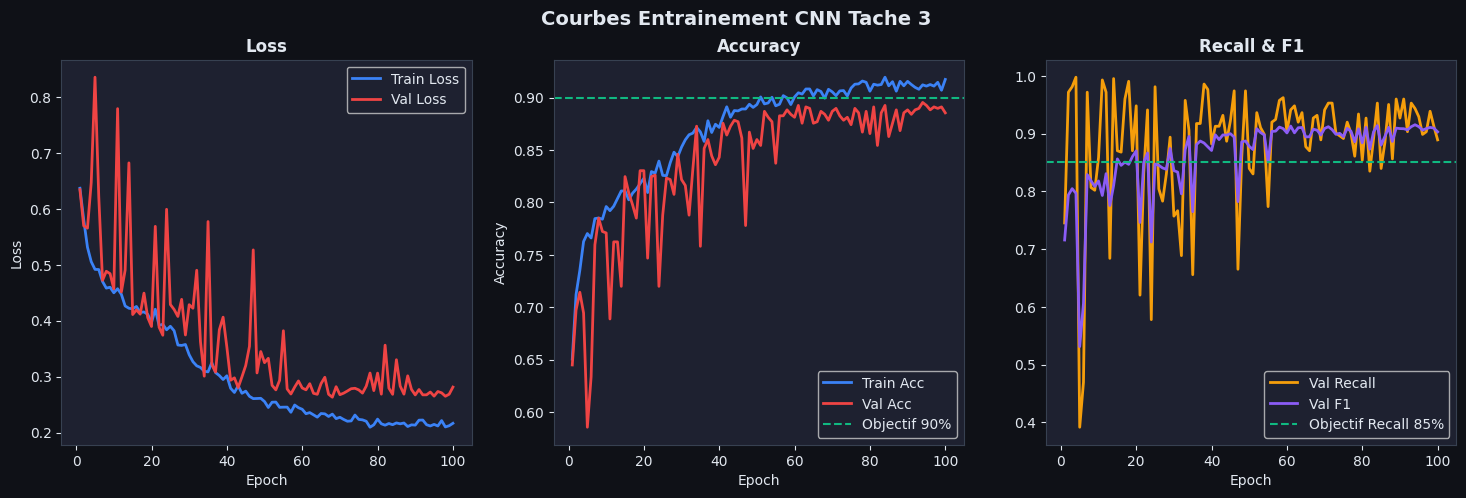

In [11]:
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f1117')
BG, TEXT = '#1e2130', '#e2e8f0'

def style_ax(ax, title):
    ax.set_facecolor(BG)
    ax.set_title(title, color=TEXT, fontsize=12, fontweight='bold')
    ax.tick_params(colors=TEXT)
    for spine in ax.spines.values(): spine.set_edgecolor('#374151')
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.legend(facecolor=BG, labelcolor=TEXT)

axes[0].plot(epochs_range, history['train_loss'], color='#3b82f6', label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'],   color='#ef4444', label='Val Loss',   linewidth=2)
style_ax(axes[0], 'Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')

axes[1].plot(epochs_range, history['train_acc'], color='#3b82f6', label='Train Acc', linewidth=2)
axes[1].plot(epochs_range, history['val_acc'],   color='#ef4444', label='Val Acc',   linewidth=2)
axes[1].axhline(0.90, color='#10b981', linestyle='--', linewidth=1.5, label='Objectif 90%')
style_ax(axes[1], 'Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')

axes[2].plot(epochs_range, history['val_recall'], color='#f59e0b', label='Val Recall', linewidth=2)
axes[2].plot(epochs_range, history['val_f1'],     color='#8b5cf6', label='Val F1',     linewidth=2)
axes[2].axhline(0.85, color='#10b981', linestyle='--', linewidth=1.5, label='Objectif Recall 85%')
style_ax(axes[2], 'Recall & F1')
axes[2].set_xlabel('Epoch')

fig.suptitle('Courbes Entrainement CNN Tache 3', color=TEXT, fontsize=14, fontweight='bold')
plt.show()


--- EVALUATION FINALE SUR LE TEST SET ---
Accuracy : 0.8884  (objectif > 0.90)
Recall   : 0.9318  (objectif > 0.85)
F1-Score : 0.9093


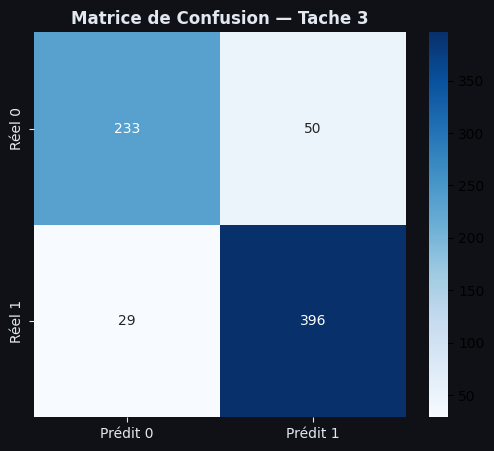

In [12]:
print("\n--- EVALUATION FINALE SUR LE TEST SET ---")
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds   = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

acc    = accuracy_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds, zero_division=0)
f1     = f1_score(all_labels, all_preds, zero_division=0)
print(f"Accuracy : {acc:.4f}  (objectif > 0.90)")
print(f"Recall   : {recall:.4f}  (objectif > 0.85)")
print(f"F1-Score : {f1:.4f}")

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1e2130')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Prédit 0', 'Prédit 1'],
            yticklabels=['Réel 0', 'Réel 1'])
ax.set_title('Matrice de Confusion — Tache 3', color='#e2e8f0', fontweight='bold')
ax.tick_params(colors='#e2e8f0')
plt.show()